In [1]:

from pprint import pprint
from typing import TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display

# from langchain.tools import tool
# from langchain_ollama import ChatOllama
from langfuse import Langfuse, observe
from langgraph.graph import END, START, StateGraph
from ollama import chat
from tools import Top_Type, code_extraction, equi_check, linter, netlist


In [2]:
load_dotenv()

True

In [3]:
class RtlAgent(TypedDict):
    user_inp:str
    spec_out:str
    code_gen:str
    extracted_code:str
    linter_out:dict
    lint_repair_count:int
    stat:dict
    # top_name:str
    # cir_type:str
    netlist_out:dict
    netlist_pass:str
    # netlist_repair_count:int
    equi_out:dict
    equi_pass:str
    # equi_repair_count:int




In [4]:
Langfuse()

In [5]:
Ollama_MODEL="qwen2.5-coder:7b"

In [6]:
SPECIFICATION_SYSTEM_PROMPT = r"""
ROLE  
You are an RTL specification extractor.

INSTRUCTIONS  
Convert the user's request into the minimum information required to generate synthesizable Verilog-2001 RTL.  
Extract only explicitly stated requirements. Never invent behavior.

STEPS  
1. Identify module name and COMBINATIONAL/SEQUENTIAL type.  
2. Extract exact ports, directions, widths and signedness when stated.  
3. Extract clock/reset only when stated.  
4. Convert required functionality into short, unambiguous behavior rules.  
5. List FSM states only when explicitly required or clearly defined.  
6. Preserve numeric parameters exactly.

END GOAL  
Return one compact machine-readable RTL contract for the code generator.

NARROWING CONSTRAINTS  
- JSON only; no Markdown or explanation.
- Do not add assumptions, corner cases, optimizations, timing, latency, protocols or error handling unless explicitly specified.
- Do not duplicate information.
- Do not infer missing widths, resets, states or functionality.
- Unknown values = null.
- Use exact user signal/module names.
- Each behavior item must describe one implementation requirement.
- No RTL/code generation.

OUTPUT
{
  "module": "",
  "type":"",
  "ports": [
    {"name":"","dir":"input|output|inout","width":null,"signed":null}
  ],
  "clock": {"name":null,"edge":null},
  "reset": {"name":null,"edge":null,"async":null},
  "parameters": {},
  "behavior": [],
  "states": []
}
"""

In [7]:
@observe(name="Specification_generator")
def spec_analyzer(state:RtlAgent)->dict:
    prompt=state['user_inp']
    resp=chat(model=Ollama_MODEL,messages=[{"role":"System",
                                                  "content":f""" {SPECIFICATION_SYSTEM_PROMPT} """},
                                                  {"role":"user",
                                                   "content":f"{prompt}"}],
                                                   stream=False,
                                                   options={
                                                            "temperature":0.25,
                                                            "top_p":0.9,
                                                            "top_k":20,
                                                            "seed":0
                                                          })
    response=resp["message"]["content"]
       
    return{
        "spec_out":response
    }

In [8]:
_VERILOG_SYSTEM =""" 
ROLE
You are a senior RTL design engineer specializing in synthesizable Verilog-2001.

INSTRUCTIONS
Implement the user's specification exactly. Generate clean, synthesizable RTL.
Use Verilog-2001 only and return only the complete Verilog code.

STEPS

1. Identify all signals, their widths, signedness, clocks, resets, and required behavior.
2. Generate the RTL using correct sequential and combinational coding styles.
3. Before returning, check syntax, widths, constants, signedness, bit selections, and synthesis safety.

END GOAL
Produce Verilator/Icarus-compatible Verilog-2001 RTL with no width or syntax errors.

NARROW CONSTRAINTS

* Use explicit signal widths.
* Every sized numeric literal must have enough bits for all specified digits.
  Example: 3'b111, NOT 2'b111.
* Match constant widths to the destination/comparison signal where practical.
  Example: reg [2:0] count → 3'b111 or 3'd7.
* Never select bits outside a signal's declared range.
* Use '=' in always @(*) and '<=' in clocked always blocks.
* Give combinational outputs a value on every path.
* Include default in case statements.
* Use $signed/$unsigned when signedness matters.
* No SystemVerilog: logic, always_comb, always_ff, typedef, enum, struct, interface, class, etc.
* Do not invent requirements or modify the user's specification.
* Return ONLY Verilog-2001 code; no Markdown or explanation.

"""

In [9]:
@observe(name="Code_generator")
def code_gen(state:RtlAgent)->dict:
    """ 
    Code generation uses ollama to generate verilgo code based on the specificaiton provided .
        INPUT:
        prompt: excepts user promtp a string providing the detials about the verilog code to be written by the llm.
    
        OUTPTS:
            gives the code as output 
    """
    prompt=state["spec_out"]
    out=chat(model=Ollama_MODEL,messages=[
                                                    {
                                                        "role": "system",
                                                        "content": _VERILOG_SYSTEM
                                                    },
                                                    {
                                                        "role": "user",
                                                        "content": prompt
                                                    }
                                                ],
                                                stream=False,
                                                options={
                                                        "temperature":0.45,
                                                         "top_p":0.8,
                                                         "top_k":20,
                                                         "seed":0
                                                         })
    resp=out["message"]["content"]
        
    return {
        "code_gen":resp,
    }

In [10]:
def extraction(state:RtlAgent)->dict:
    """ 
    Invokes code extractor fucntion from tools and returns clean code.
    """
    code=state["code_gen"]
    out=code_extraction(code)
    return {
        "extracted_code":out
    }

In [11]:
def lint(state:RtlAgent)->dict:
    """
    Invokes linetr function form tools and returns lint result 
    """
    code=state["extracted_code"]
    out=linter(code=code)
    lint_out={
        "lint_returncode":out["return_code"],
        "lint_stdout":out["stdout"],
        "lint_err":out["stderr"]
    }
    return{
        "linter_out":lint_out
    }

In [12]:
def top_type(state:RtlAgent)->dict:
    """ 
    Invokes toptype func form tools and returns top_name, type of circuit
    """
    code=state["extracted_code"]
    out=Top_Type(code=code)
    return {
        "stat":out
    }

In [13]:
@observe(name="Netlist_generaion")
def netlist_gen(state:RtlAgent)->dict:
    """ 
    invokes netlist func form tool and returns  
    """
    top_name=state["stat"]["top_module"]
    lib_path="../Nangate45/Nangate45_typ.lib"
    netgen=netlist(top=top_name,module_path=f"./src/{top_name}.v",lib_path=lib_path)
    net_pass="fail"
    if netgen["netlist_returncode"]== 0:
        net_pass="pass"

    return{
        "netlist_out":netgen,
        "netlist_pass":net_pass
    }

In [14]:
@observe(name="Equivalency_checking")
def equi(state:RtlAgent)->dict:
    top_name=state["stat"]["top_module"]
    cir_type=state["stat"]["type"]
    path_1=f"./src/{top_name}.v"
    path_2=f"./src/{top_name}_netlist.v"
    equi_out=equi_check(top=top_name,path_1=path_1,path_2=path_2,design_type=cir_type)

    return {
        "equi_out":equi_out,
        "equi_pass":equi_out["pass"]
    }

In [15]:
graph=StateGraph(RtlAgent)
graph.add_node("spec_out",spec_analyzer)
graph.add_node("code_gen",code_gen)
graph.add_node("extracted_code",extraction)
graph.add_node("linter_out",lint)
graph.add_node("stat",top_type)
graph.add_node("netlist_out",netlist_gen)
graph.add_node("equi_out",equi)

# adding edges
graph.add_edge(START,"spec_out")
graph.add_edge("spec_out" ,"code_gen")
graph.add_edge("code_gen","extracted_code")
graph.add_edge("extracted_code","linter_out")
graph.add_edge("linter_out","stat")
graph.add_edge("stat","netlist_out")
graph.add_edge("netlist_out","equi_out")
graph.add_edge("equi_out",END)

builder=graph.compile()

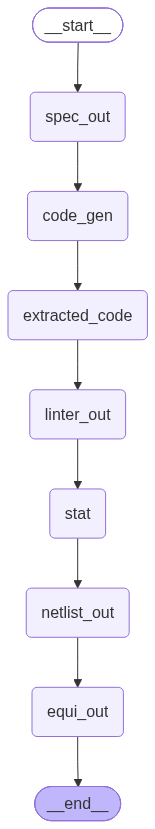

In [16]:
display(Image(builder.get_graph().draw_mermaid_png()))

In [19]:
input_state={"user_inp":"Design a 32 bit apb completer with 50Mhz operating frequency",
             }

resp=builder.invoke(input=input_state) # type: ignore

In [20]:
pprint(resp)

{'code_gen': '```verilog\n'
             'module apb_completer (\n'
             '  input wire clk,\n'
             '  input wire rst_n,\n'
             '  output reg [31:0] paddr,\n'
             '  output reg psel,\n'
             '  output reg penable,\n'
             '  output reg pwrite,\n'
             '  output reg [31:0] pwdata,\n'
             '  input wire [31:0] prdata,\n'
             '  input wire pready,\n'
             '  output reg pslverr\n'
             ');\n'
             '\n'
             'always @(posedge clk or negedge rst_n) begin\n'
             '  if (!rst_n) begin\n'
             "    psel <= 1'b0;\n"
             "    penable <= 1'b0;\n"
             "    pwrite <= 1'b0;\n"
             "    pwdata <= 32'd0;\n"
             "    pslverr <= 1'b0;\n"
             '  end else begin\n'
             '    if (pready) begin\n'
             "      psel <= 1'b1;\n"
             "      penable <= 1'b1;\n"
             '      if (pwrite) begin\n'
             '        p